# Plot Trained Model Predictions by Time Slice

Use this notebook to select one or more timestamps, load the matching model predictions from `../outputs/Our_results_trained_models_2mT.pkl`, and compare selected models. The plotting palette is `viridis`, matching the original `imshow` style and the GIF export in `models_inference.ipynb`. Set `use_fixed_color_scale = False` for GIF-style local percentile clipping and higher contrast on each selected time slice.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Work from the notebook location.
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = Path('notebooks') if Path('notebooks').exists() else NOTEBOOK_DIR

RESULTS_FILE = (NOTEBOOK_DIR / '../outputs/Our_results_trained_models_2mT.pkl').resolve()
TARGET_VAR = '2mT'
PLOT_VAR = '2mT'
# models_inference.ipynb uses imshow's default palette, and the GIF export uses viridis explicitly.
CMAP = 'viridis'

print(f'Loading: {RESULTS_FILE}')
results_df = pd.read_pickle(RESULTS_FILE)
results_df['time_step'] = pd.to_datetime(results_df['time_step'])

plot_df = results_df[
    (results_df['target_var'] == TARGET_VAR)
    & (results_df['variable'] == PLOT_VAR)
].copy()

available_models = sorted(plot_df['model'].unique())
print(f'\nAvailable models for {TARGET_VAR} / {PLOT_VAR} ({len(available_models)}):')
for i, name in enumerate(available_models, 1):
    print(f'  {i:2d}. {name}')
print(f'\nAvailable timestamps: {len(plot_df["time_step"].unique())}')
print('Copy names exactly from the list above into model_order.')

results_df.head()

Loading: /mnt/data/chuongtnd/LDM-downscaling/outputs/Our_results_trained_models_2mT.pkl

Available models for 2mT / 2mT (19):
   1. COSMO-CLM
   2. ERA5
   3. GAN
   4. LDM_PDE_res
   5. LDM_res
   6. LMM_PDE_res
   7. LMM_PDE_res_020_1_inv_ni
   8. LMM_PDE_res_020_2_inv_ni
   9. LMM_PDE_res_020_3_inv_ni
  10. LMM_PDE_res_020_4_inv_ni
  11. LMM_PDE_res_020_5_inv_ni
  12. LMM_PDE_res_033_1_inv_ni
  13. LMM_PDE_res_033_2_inv_ni
  14. LMM_PDE_res_033_3_inv_ni
  15. LMM_PDE_res_033_4_inv_ni
  16. LMM_PDE_res_033_5_inv_ni
  17. Linear Interp.
  18. Quadratic Interp.
  19. UNET

Available timestamps: 165
Copy names exactly from the list above into model_order.


,input_var,target_var,model,variable,spat_distr,min,max,time_step
0,all,2mT,LDM_res,2mT,"[[tensor(285.3527), tensor(284.8631), tensor(2...",271.939619,290.946573,2014-04-24 02:00:00
1,all,2mT,LDM_res,2mT,"[[tensor(273.5956), tensor(273.2779), tensor(2...",258.530014,289.697899,2014-12-28 03:00:00
2,all,2mT,LDM_res,2mT,"[[tensor(289.5651), tensor(288.9934), tensor(2...",279.464790,300.903473,2019-09-02 02:00:00
3,all,2mT,LDM_res,2mT,"[[tensor(290.4320), tensor(290.2303), tensor(2...",272.372097,302.943578,2006-05-14 10:00:00
4,all,2mT,LDM_res,2mT,"[[tensor(279.8655), tensor(279.8720), tensor(2...",268.237921,291.027161,2016-05-02 04:00:00


## Choose Time Slices and Models

Run the **load** cell first — it prints every `model` name in the pickle file. Copy those strings exactly into `model_order` (or set `model_order = None` to plot all models).

Edit `time_slices` for fixed timestamps. Set `n_random_time_slices` to add extra random timestamps from the file (`0` = hardcoded only).

Then run the **validate selection** cell before plotting.


In [ ]:
# Example requested format: '2014-04-24 02:00:00'
# 0 = only hardcoded timestamps below; N = add N random timestamps from the pickle file.
n_random_time_slices = 4
# Set to an int for reproducible random picks, or None for a different sample each run.
random_time_slice_seed = 42

time_slices = [
    '2014-04-24 02:00:00',
    # '2014-12-28 03:00:00',
    # '2016-05-02 04:00:00',
    # '2006-05-14 10:00:00',
    # '2019-09-02 02:00:00',
]

# Use None for all models in the file, or choose a subset/order, for example:
# model_order = ['ERA5', 'COSMO-CLM', 'UNET', 'GAN', 'LDM_res', 'LDM_PDE_res', 'LMM_PDE_res']
model_order = ['COSMO-CLM', 'LDM_res', 'LDM_PDE_res', 'LMM_PDE_res_033_2_inv_ni', 'LMM_PDE_res_020_2_inv_ni']

# Exclude models from the plot, for example: ['ERA5']
exclude_models = ['ERA5']

# True: one fixed scale across the full results file.
# False: use percentile clipping for each selected time slice, matching the GIF export style.
use_fixed_color_scale = False

# Percentiles used when use_fixed_color_scale=False. The GIF export in models_inference.ipynb uses (0.5, 99.5).
local_contrast_percentiles = (0.5, 99.5)

# Arrange each timestamp's model panels into this many rows.
n_model_rows = 2

hardcoded_times = pd.to_datetime(list(time_slices))
available_times = pd.Index(sorted(plot_df['time_step'].unique()))

n_random = int(n_random_time_slices)
if n_random < 0:
    raise ValueError('n_random_time_slices must be >= 0')

if n_random == 0:
    selected_times = hardcoded_times
    random_picks = pd.DatetimeIndex([])
else:
    pool = available_times.difference(hardcoded_times)
    if n_random > len(pool):
        raise ValueError(
            f'Requested {n_random} random time slice(s) but only {len(pool)} available '
            f'after excluding {len(hardcoded_times)} hardcoded timestamp(s).'
        )
    rng = np.random.default_rng(random_time_slice_seed)
    random_picks = pd.to_datetime(
        rng.choice(pool.to_numpy(), size=n_random, replace=False)
    )
    selected_times = pd.DatetimeIndex(list(hardcoded_times) + list(random_picks))

print(f'Hardcoded time slices ({len(hardcoded_times)}):')
for ts in hardcoded_times:
    print(f'  {ts}')
if n_random:
    print(f'Random time slices ({len(random_picks)}):')
    for ts in random_picks:
        print(f'  {ts}')
print(f'Total selected: {len(selected_times)}')
selected_times


DatetimeIndex(['2014-04-24 02:00:00', '2014-11-28 03:00:00',
               '2016-12-02 04:00:00', '2006-01-14 10:00:00',
               '2019-06-02 02:00:00'],
              dtype='datetime64[ns]', freq=None)

In [14]:
# Rebuild plot_df if you changed TARGET_VAR / PLOT_VAR in the load cell.
plot_df = results_df[
    (results_df['target_var'] == TARGET_VAR)
    & (results_df['variable'] == PLOT_VAR)
].copy()

available_models = sorted(plot_df['model'].unique())
available_times = pd.Index(sorted(plot_df['time_step'].unique()))

requested = available_models if model_order is None else list(model_order)
exclude = set(exclude_models or [])
selected = [m for m in requested if m not in exclude]
missing = [m for m in selected if m not in set(available_models)]

if missing:
    print('These names in model_order are NOT in the pickle file:')
    for name in missing:
        hints = [a for a in available_models if name[:10] in a or a[:10] in name]
        hint = f'  -> similar: {hints}' if hints else ''
        print(f'  {name!r}{hint}')
    print('\nAvailable models (copy exactly):')
    for i, name in enumerate(available_models, 1):
        print(f'  {i:2d}. {name}')
    raise ValueError(f'Missing requested models: {missing}')

print(f'Will plot {len(selected)} model(s): {selected}')
print(f'Available timestamps: {len(available_times)} ({available_times[0]} .. {available_times[-1]})')

Will plot 5 model(s): ['COSMO-CLM', 'LDM_res', 'LDM_PDE_res', 'LMM_PDE_res_033_2_inv_ni', 'LMM_PDE_res_020_2_inv_ni']
Available timestamps: 165 (2000-01-01 15:00:00 .. 2020-12-02 20:00:00)


In [15]:
def as_array(value):
    """Convert saved tensors/xarray/numpy objects into a 2-D numpy array for imshow."""
    if hasattr(value, 'detach'):
        value = value.detach().cpu().numpy()
    elif hasattr(value, 'values'):
        value = value.values
    try:
        return np.asarray(value, dtype=float).squeeze()
    except (TypeError, ValueError):
        return np.asarray(value).squeeze()


def color_limits(df):
    """Use the saved robust percentiles for a stable global scale."""
    return float(df['min'].min()), float(df['max'].max())


def percentile_color_limits(df, percentiles=(0.5, 99.5)):
    """Match the GIF export style: percentile clipping over the arrays being plotted."""
    arrays = [as_array(value) for value in df['spat_distr']]
    stacked = np.stack(arrays, axis=0)
    vmin = float(np.nanpercentile(stacked, percentiles[0]))
    vmax = float(np.nanpercentile(stacked, percentiles[1]))
    return vmin, vmax


def resolve_models(df, model_order=None, exclude=None):
    available = list(df['model'].drop_duplicates())
    models = available if model_order is None else list(model_order)
    exclude = set(exclude or [])
    models = [model for model in models if model not in exclude]

    missing_models = [model for model in models if model not in set(available)]
    if missing_models:
        raise ValueError(
            f'Missing requested models: {missing_models}\n'
            f'Available models: {available}'
        )
    if not models:
        raise ValueError('No models left to plot after applying exclude_models.')
    return models


def validate_times(df, times):
    available_times = set(df['time_step'])
    missing_times = [ts for ts in times if ts not in available_times]
    if missing_times:
        nearest = {
            str(ts): str(df.iloc[(df['time_step'] - ts).abs().argsort()[:1]]['time_step'].iloc[0])
            for ts in missing_times
        }
        raise ValueError(f'Missing requested timestamps. Nearest available matches: {nearest}')


def plot_time_slice(
    df,
    ts,
    models,
    use_fixed_scale=True,
    fixed_vmin=None,
    fixed_vmax=None,
    local_percentiles=(0.5, 99.5),
    n_rows=2,
    cmap=CMAP,
    figsize_per_panel=(3.6, 3.2),
    save_path=None,
):
    ts = pd.to_datetime(ts)
    time_df = df[df['time_step'] == ts]
    selected_df = time_df[time_df['model'].isin(models)]

    if use_fixed_scale:
        vmin, vmax = fixed_vmin, fixed_vmax
        scale_label = 'fixed global scale'
    else:
        vmin, vmax = percentile_color_limits(selected_df, percentiles=local_percentiles)
        scale_label = f'local percentile scale p{local_percentiles[0]}-p{local_percentiles[1]}'

    n_rows = max(1, min(int(n_rows), len(models)))
    n_cols = int(np.ceil(len(models) / n_rows))
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )

    image = None
    for idx, model in enumerate(models):
        row, col = divmod(idx, n_cols)
        ax = axes[row, col]
        match = time_df[time_df['model'] == model]
        if match.empty:
            ax.set_visible(False)
            continue

        arr = as_array(match.iloc[0]['spat_distr'])
        image = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(model, fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes.flat[len(models):]:
        ax.set_visible(False)

    cbar = fig.colorbar(image, ax=axes, shrink=0.85, pad=0.01)
    cbar.set_label(f'{PLOT_VAR} [K]')
    fig.suptitle(f'{PLOT_VAR} predictions | {ts} | {scale_label} ({vmin:.2f}, {vmax:.2f})', fontsize=14)

    if save_path is not None:
        save_path = Path(save_path)
        fig.savefig(save_path, dpi=180, bbox_inches='tight')
        print(f'Saved figure: {save_path}')

    return fig, axes


def plot_selected_time_slices(
    df,
    times,
    model_order=None,
    exclude_models=None,
    use_fixed_scale=True,
    local_percentiles=(0.5, 99.5),
    n_rows=2,
):
    times = list(pd.to_datetime(times))
    validate_times(df, times)
    models = resolve_models(df, model_order=model_order, exclude=exclude_models)

    fixed_vmin, fixed_vmax = color_limits(df)
    print(f'Plotting models: {models}')
    if use_fixed_scale:
        print(f'Using fixed global color scale: vmin={fixed_vmin:.3f}, vmax={fixed_vmax:.3f}')
    else:
        print(f'Using local percentile color scale: p{local_percentiles[0]}-p{local_percentiles[1]}')

    figures = []
    for ts in times:
        fig, axes = plot_time_slice(
            df,
            ts,
            models=models,
            use_fixed_scale=use_fixed_scale,
            fixed_vmin=fixed_vmin,
            fixed_vmax=fixed_vmax,
            local_percentiles=local_percentiles,
            n_rows=n_rows,
        )
        figures.append((fig, axes))
        plt.show()

    return figures


def compute_zoom_bounds(
    ny,
    nx,
    zoom_size_percent,
    center_x_offset_percent=0.0,
    center_y_offset_percent=0.0,
):
    """Return slice bounds (y0, y1, x0, x1) for a centered crop with optional shift.

    zoom_size_percent: side length as % of full map (smaller = stronger zoom).
    center_*_offset_percent: shift crop center from map center, as % of full width/height.
        Positive x moves the box right; positive y moves the box down.
    """
    zoom_size_percent = float(zoom_size_percent)
    if not (0 < zoom_size_percent <= 100):
        raise ValueError('zoom_size_percent must be in (0, 100].')

    crop_h = max(1, int(round(ny * zoom_size_percent / 100.0)))
    crop_w = max(1, int(round(nx * zoom_size_percent / 100.0)))
    crop_h = min(crop_h, ny)
    crop_w = min(crop_w, nx)

    cx = nx / 2.0 + nx * float(center_x_offset_percent) / 100.0
    cy = ny / 2.0 + ny * float(center_y_offset_percent) / 100.0

    x0 = int(round(cx - crop_w / 2.0))
    y0 = int(round(cy - crop_h / 2.0))
    x0 = max(0, min(x0, nx - crop_w))
    y0 = max(0, min(y0, ny - crop_h))
    return y0, y0 + crop_h, x0, x0 + crop_w


def crop_array(arr, bounds):
    y0, y1, x0, x1 = bounds
    return arr[y0:y1, x0:x1]


def plot_time_slice_zoom(
    df,
    ts,
    models,
    overview_model,
    zoom_size_percent=40.0,
    center_x_offset_percent=0.0,
    center_y_offset_percent=0.0,
    use_fixed_scale=True,
    fixed_vmin=None,
    fixed_vmax=None,
    local_percentiles=(0.5, 99.5),
    n_rows=2,
    cmap=CMAP,
    figsize_per_panel=(3.6, 3.2),
    rect_color='red',
    rect_linewidth=1.8,
    save_path=None,
):
    """Overview panel (not zoomed) + zoomed panels for every model.

    The overview panel uses `overview_model` (default COSMO-CLM) on the full domain
    with a rectangle marking the zoom region. Remaining panels show the same crop
    for each model in `models`.
    """
    from matplotlib.patches import Rectangle

    ts = pd.to_datetime(ts)
    time_df = df[df['time_step'] == ts]
    selected_df = time_df[time_df['model'].isin(models)]

    if use_fixed_scale:
        vmin, vmax = fixed_vmin, fixed_vmax
        scale_label = 'fixed global scale'
    else:
        vmin, vmax = percentile_color_limits(selected_df, percentiles=local_percentiles)
        scale_label = f'local percentile scale p{local_percentiles[0]}-p{local_percentiles[1]}'

    overview_rows = time_df[time_df['model'] == overview_model]
    if overview_rows.empty:
        raise ValueError(
            f'overview_model {overview_model!r} not found at {ts}. '
            f'Available: {sorted(time_df["model"].unique())}'
        )

    ref_arr = as_array(overview_rows.iloc[0]['spat_distr'])
    if ref_arr.ndim != 2:
        raise ValueError(f'Expected 2-D field, got shape {ref_arr.shape}')
    ny, nx = ref_arr.shape
    bounds = compute_zoom_bounds(
        ny,
        nx,
        zoom_size_percent,
        center_x_offset_percent=center_x_offset_percent,
        center_y_offset_percent=center_y_offset_percent,
    )
    y0, y1, x0, x1 = bounds

    n_panels = 1 + len(models)
    n_rows = max(1, min(int(n_rows), n_panels))
    n_cols = int(np.ceil(n_panels / n_rows))
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
        constrained_layout=True,
    )

    image = None
    for panel_idx in range(n_panels):
        row, col = divmod(panel_idx, n_cols)
        ax = axes[row, col]
        if panel_idx == 0:
            model = overview_model
            arr_show = ref_arr
            title = f'{overview_model} (full)'
        else:
            model = models[panel_idx - 1]
            match = time_df[time_df['model'] == model]
            if match.empty:
                ax.set_visible(False)
                continue
            arr = as_array(match.iloc[0]['spat_distr'])
            arr_show = crop_array(arr, bounds)
            title = f'{model} (zoom)'

        image = ax.imshow(arr_show, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

        if panel_idx == 0:
            crop_w, crop_h = x1 - x0, y1 - y0
            ax.add_patch(
                Rectangle(
                    (x0, y0),
                    crop_w,
                    crop_h,
                    fill=False,
                    edgecolor=rect_color,
                    linewidth=rect_linewidth,
                )
            )

    for ax in axes.flat[n_panels:]:
        ax.set_visible(False)

    cbar = fig.colorbar(image, ax=axes, shrink=0.85, pad=0.01)
    cbar.set_label(f'{PLOT_VAR} [K]')
    zoom_label = (
        f'zoom {zoom_size_percent:.1f}% | offset x={center_x_offset_percent:+.1f}% '
        f'y={center_y_offset_percent:+.1f}% | crop rows [{y0}:{y1}] cols [{x0}:{x1}]'
    )
    fig.suptitle(
        f'{PLOT_VAR} zoomed comparison | {ts} | {scale_label} ({vmin:.2f}, {vmax:.2f})\n{zoom_label}',
        fontsize=12,
    )

    if save_path is not None:
        save_path = Path(save_path)
        fig.savefig(save_path, dpi=180, bbox_inches='tight')
        print(f'Saved figure: {save_path}')

    return fig, axes, bounds


def plot_selected_time_slices_zoom(
    df,
    times,
    models,
    overview_model,
    zoom_size_percent=40.0,
    center_x_offset_percent=0.0,
    center_y_offset_percent=0.0,
    use_fixed_scale=True,
    local_percentiles=(0.5, 99.5),
    n_rows=2,
    **kwargs,
):
    times = list(pd.to_datetime(times))
    validate_times(df, times)

    fixed_vmin, fixed_vmax = color_limits(df)
    print(f'Zoom overview model: {overview_model}')
    print(f'Zoom panels for models: {models}')
    if use_fixed_scale:
        print(f'Using fixed global color scale: vmin={fixed_vmin:.3f}, vmax={fixed_vmax:.3f}')
    else:
        print(f'Using local percentile color scale: p{local_percentiles[0]}-p{local_percentiles[1]}')

    figures = []
    for ts in times:
        fig, axes, bounds = plot_time_slice_zoom(
            df,
            ts,
            models=models,
            overview_model=overview_model,
            zoom_size_percent=zoom_size_percent,
            center_x_offset_percent=center_x_offset_percent,
            center_y_offset_percent=center_y_offset_percent,
            use_fixed_scale=use_fixed_scale,
            fixed_vmin=fixed_vmin,
            fixed_vmax=fixed_vmax,
            local_percentiles=local_percentiles,
            n_rows=n_rows,
            **kwargs,
        )
        figures.append((fig, axes, bounds))
        plt.show()
    return figures


In [16]:
figures = plot_selected_time_slices(
    plot_df,
    selected_times,
    model_order=model_order,
    exclude_models=exclude_models,
    use_fixed_scale=use_fixed_color_scale,
    local_percentiles=local_contrast_percentiles,
    n_rows=n_model_rows,
)

ValueError: Missing requested timestamps. Nearest available matches: {'2014-11-28 03:00:00': '2014-11-30 14:00:00', '2016-12-02 04:00:00': '2016-10-12 19:00:00', '2006-01-14 10:00:00': '2006-01-02 06:00:00', '2019-06-02 02:00:00': '2019-08-09 18:00:00'}

## Optional: Plot Each Time Slice Separately

Run this cell when you want one figure per selected timestamp while preserving the same global color scale.

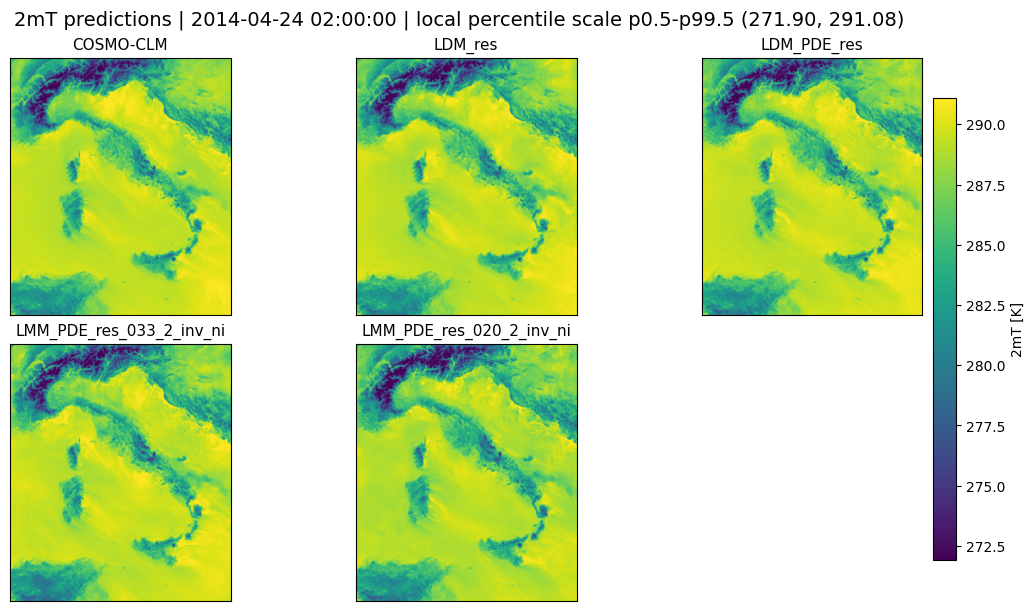

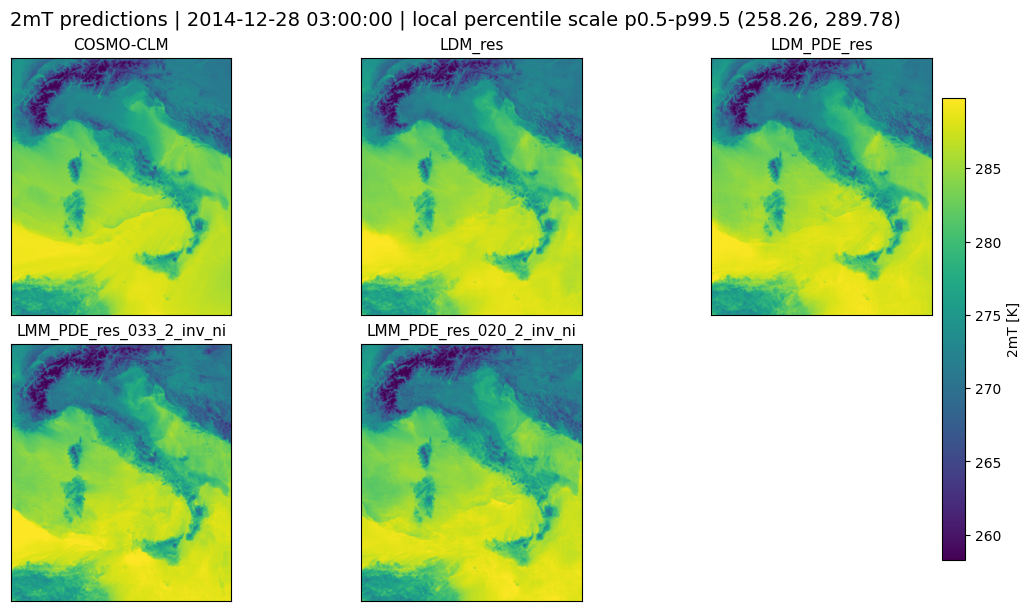

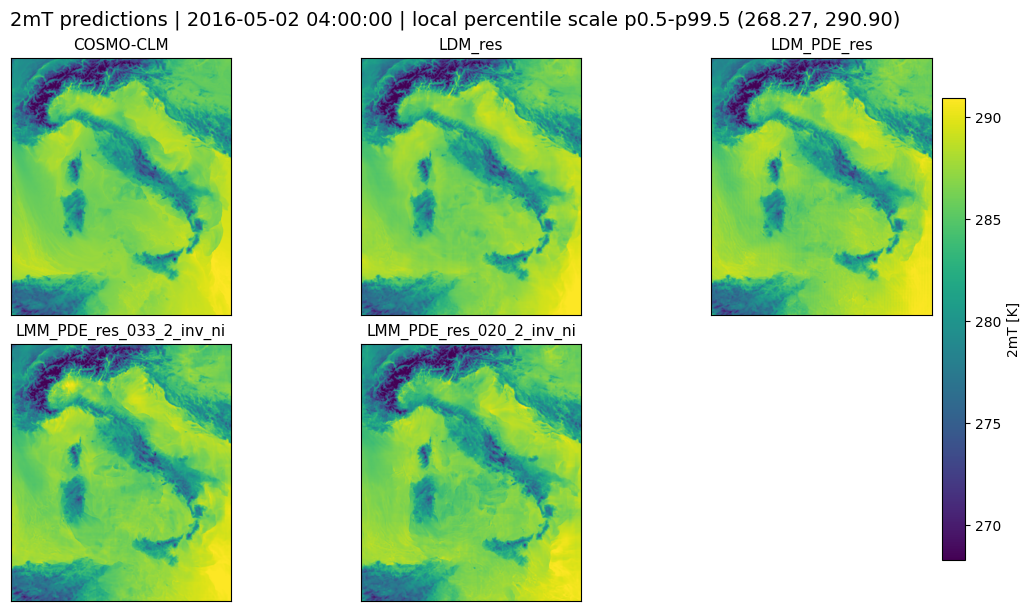

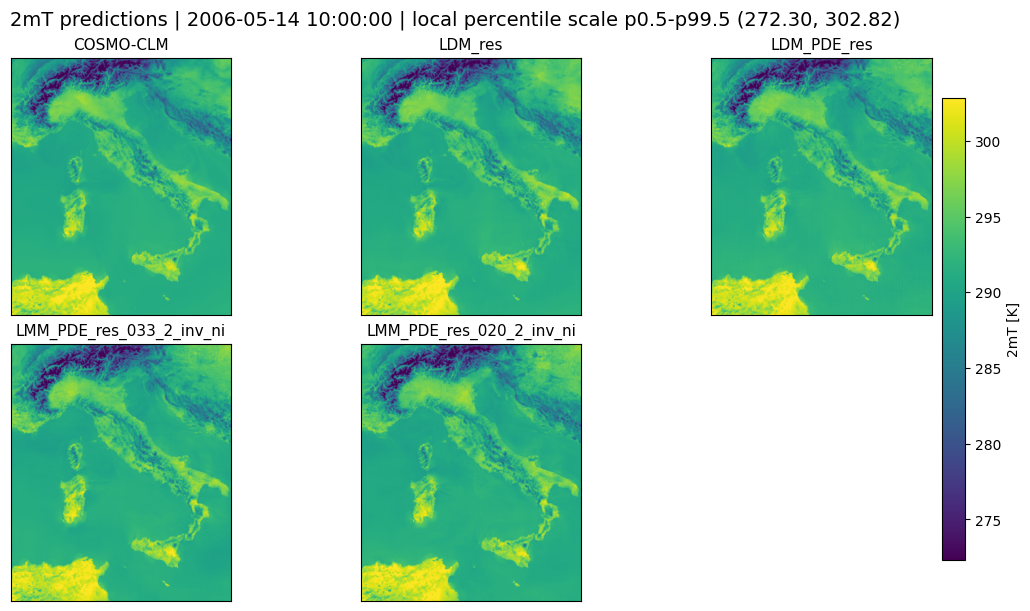

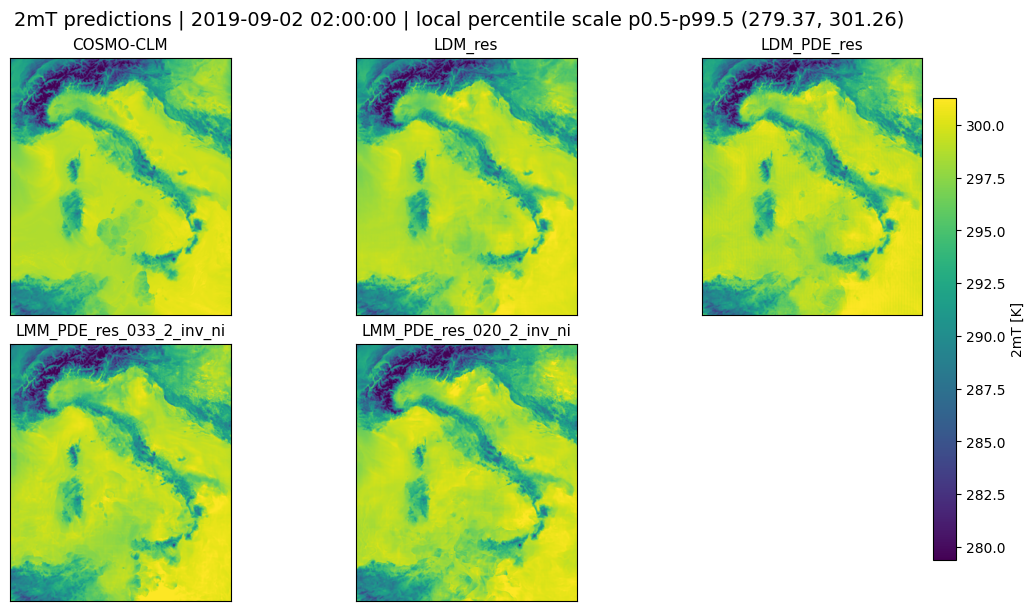

In [ ]:
models_to_plot = resolve_models(plot_df, model_order=model_order, exclude=exclude_models)
fixed_vmin, fixed_vmax = color_limits(plot_df)

for ts in selected_times:
    fig, axes = plot_time_slice(
        plot_df,
        ts,
        models=models_to_plot,
        use_fixed_scale=use_fixed_color_scale,
        fixed_vmin=fixed_vmin,
        fixed_vmax=fixed_vmax,
        local_percentiles=local_contrast_percentiles,
        n_rows=n_model_rows,
        figsize_per_panel=(3.8, 3.0),
        # save_path=NOTEBOOK_DIR / f'../outputs/predictions_{ts:%Y%m%d_%H%M}.png',
    )
    plt.show()

## Zoom Into a Map Region

The first panel shows **COSMO-CLM** (or `zoom_overview_model`) on the full domain with a rectangle marking the crop. The remaining panels show the same crop for every model in `model_order`.

- `zoom_size_percent`: side length of the crop as % of the map (smaller = stronger zoom).
- `zoom_center_x_offset_percent`: shift the crop center horizontally (% of map width; + = right).
- `zoom_center_y_offset_percent`: shift the crop center vertically (% of map height; + = down).


In [ ]:
# --- zoom controls ---
# Fraction of map width/height shown in zoom panels (smaller = more zoom).
zoom_size_percent = 40.0

# Shift crop center from geometric center (% of full map size).
zoom_center_x_offset_percent = -5.0
zoom_center_y_offset_percent = 5.0

# Full-map reference panel (rectangle drawn on this field).
zoom_overview_model = 'COSMO-CLM'

zoom_n_rows = 2
zoom_rect_color = 'red'
zoom_rect_linewidth = 1.8


Zoom overview model: COSMO-CLM
Zoom panels for models: ['COSMO-CLM', 'LDM_res', 'LDM_PDE_res', 'LMM_PDE_res_033_2_inv_ni', 'LMM_PDE_res_020_2_inv_ni']
Using local percentile color scale: p0.5-p99.5


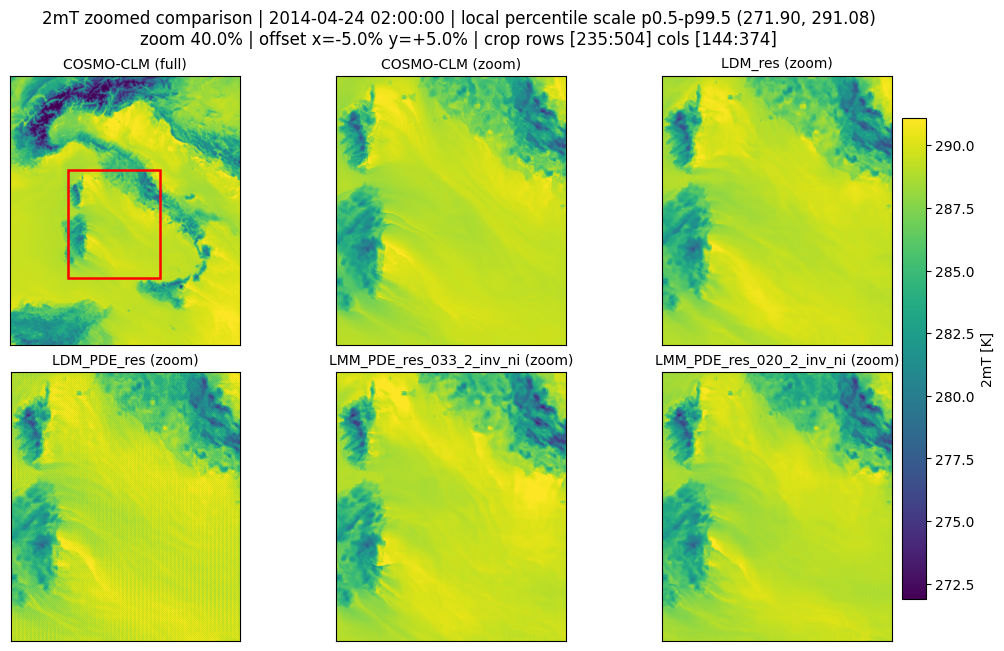

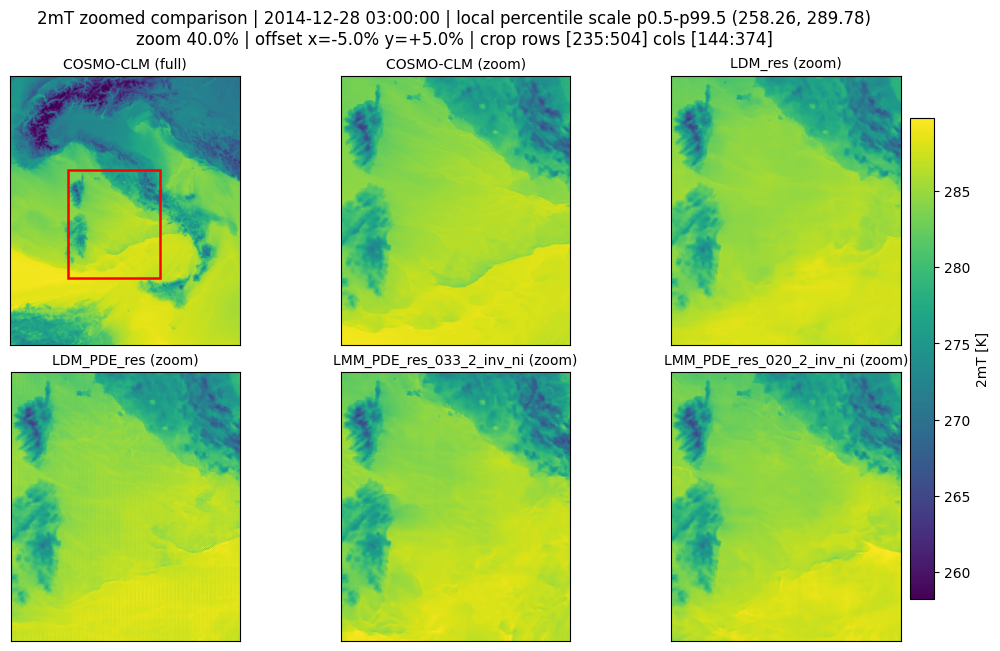

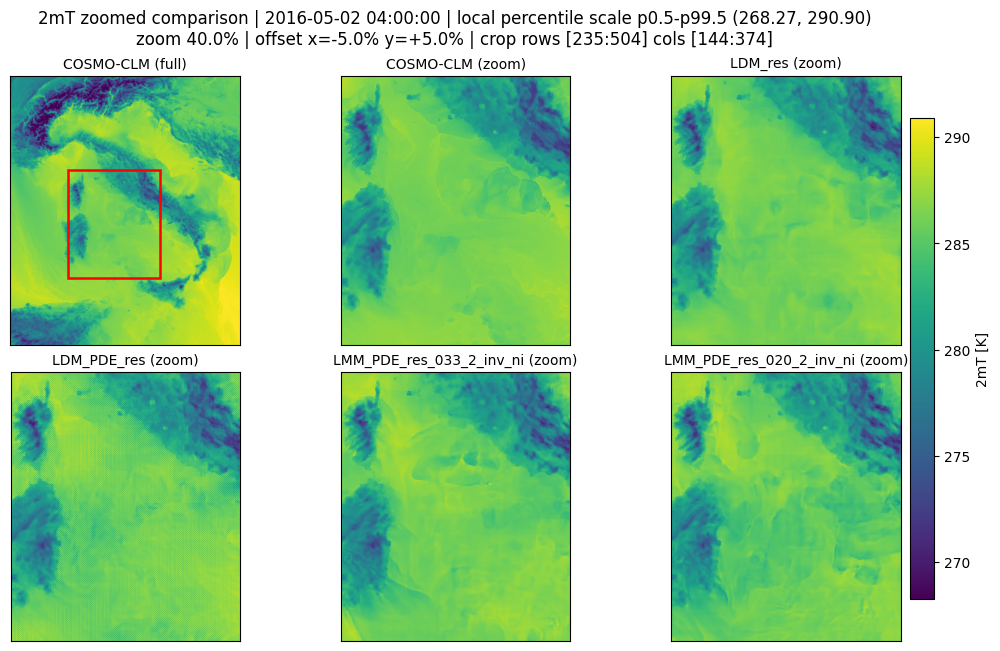

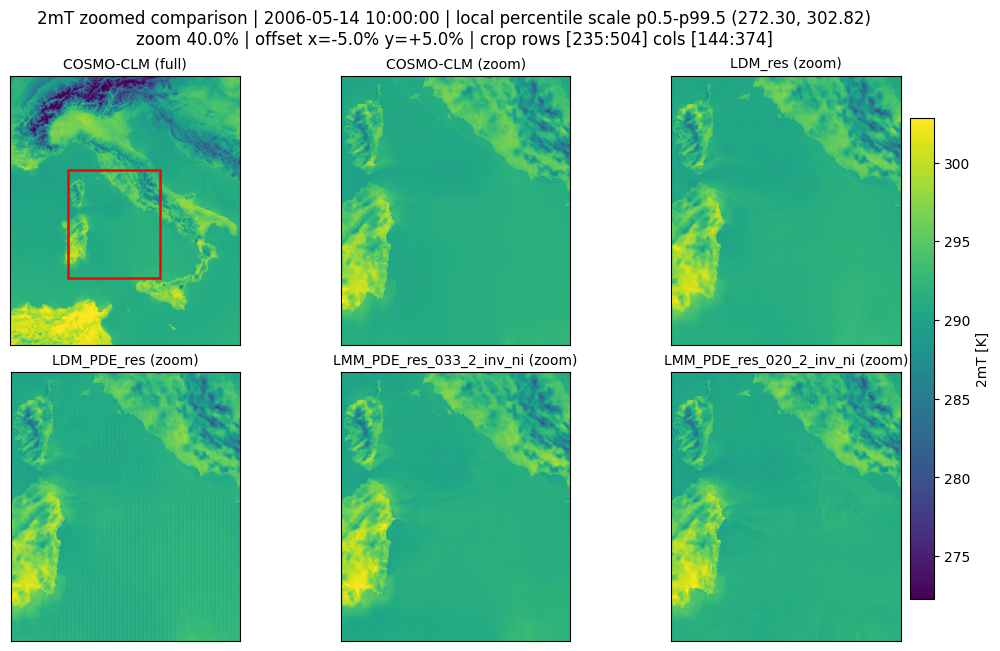

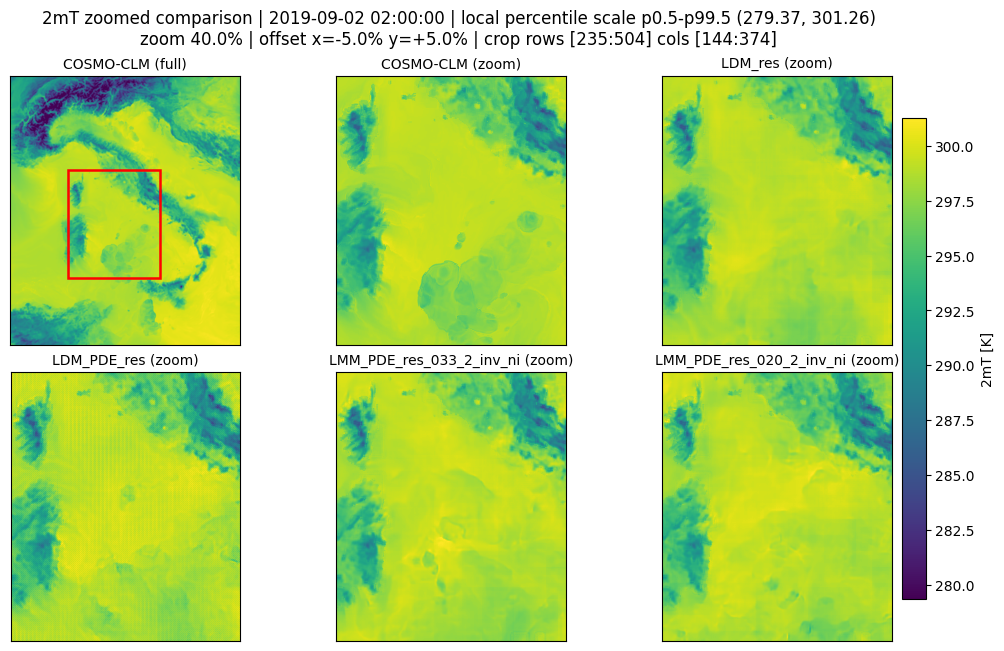

In [ ]:
models_to_plot = resolve_models(plot_df, model_order=model_order, exclude=exclude_models)

zoom_figures = plot_selected_time_slices_zoom(
    plot_df,
    selected_times,
    models=models_to_plot,
    overview_model=zoom_overview_model,
    zoom_size_percent=zoom_size_percent,
    center_x_offset_percent=zoom_center_x_offset_percent,
    center_y_offset_percent=zoom_center_y_offset_percent,
    use_fixed_scale=use_fixed_color_scale,
    local_percentiles=local_contrast_percentiles,
    n_rows=zoom_n_rows,
    rect_color=zoom_rect_color,
    rect_linewidth=zoom_rect_linewidth,
    # save_path=NOTEBOOK_DIR / f'../outputs/predictions_zoom_{selected_times[0]:%Y%m%d_%H%M}.png',
)
